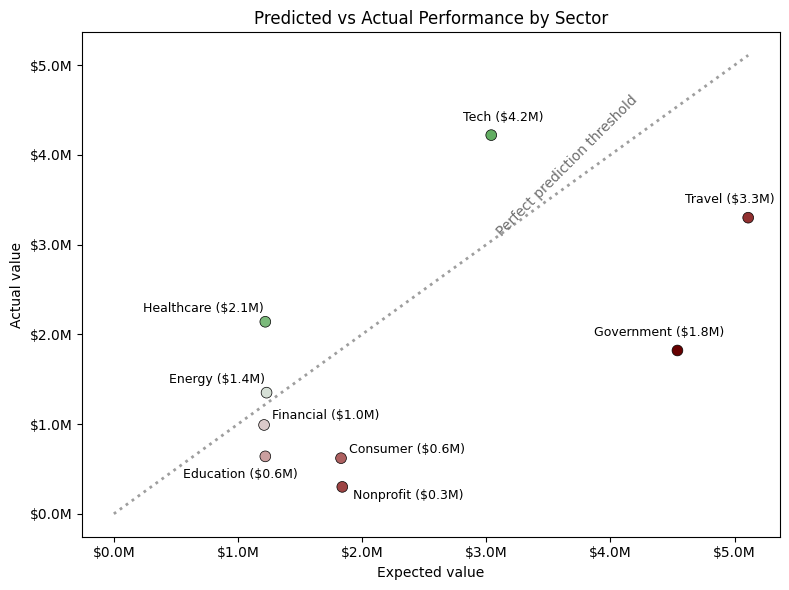

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import colorsys
import matplotlib.ticker as mtick

# Load and clean data
df = pd.read_csv("data/Assignment2-data.csv")
df["Target"] = df["Target"].replace(r"[\$,]", "", regex=True).astype(float)
df["Actual"] = df["Actual"].replace(r"[\$,]", "", regex=True).astype(float)

# Distance from perfect prediction
df["diff"] = df["Actual"] - df["Target"]

# --- Color encoding ---
max_dist = np.abs(df["diff"]).max()
colors = []
for d in df["diff"]:
    delta = abs(d) / max_dist
    hue = 120/360 if d >= 0 else 0.0
    saturation = delta
    value = 0.9 - 0.5 * delta
    colors.append(colorsys.hsv_to_rgb(hue, saturation, value))

# --- MANUAL LABEL POSITIONS (EDIT THESE FREELY) ---
# values are (dx, dy) offsets in data units
label_offsets = {
    "Travel": (-0.15, 0.2),
    "Government": (-0.15, 0.2),
    "Tech": (0.10, 0.20),
    "Consumer": (0.53, 0.1),
    "Nonprofit": (0.53, -0.1),
    "Financial": (0.5, 0.10),
    "Healthcare": (-0.5, 0.15),
    "Energy": (-0.4, 0.15),
    "Education": (-0.2, -0.20),
}

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["Target"], df["Actual"], s=60, c=colors,
           edgecolors="black", linewidths=0.5)

# Perfect prediction line
limit = max(df["Target"].max(), df["Actual"].max())
ax.plot([0, limit], [0, limit], linestyle=":", color="#9e9e9e", linewidth=2)

# Line label
mid = 0.6 * limit
ax.text(mid, mid, "Perfect prediction threshold",
        color="#6e6e6e", fontsize=10,
        rotation=45, ha="left", va="bottom")

# Dollar formatting
formatter = mtick.StrMethodFormatter("${x:.1f}M")
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

ax.set_xlabel("Expected value")
ax.set_ylabel("Actual value")
ax.set_title("Predicted vs Actual Performance by Sector")

# --- Manual labels ---
for _, row in df.iterrows():
    dx, dy = label_offsets[row["Sector"]]
    label = f"{row['Sector']} (${row['Actual']:.1f}M)"
    ax.text(row["Target"] + dx,
            row["Actual"] + dy,
            label,
            fontsize=9,
            ha="center",
            va="center")

plt.tight_layout()
plt.show()
